# Autoencoder Reconstruction

This notebook loads the trained autoencoder checkpoint, reconstructs a few test samples from the configured dataset, and saves example outputs under the model output directory.

In [1]:
from __future__ import annotations

from pathlib import Path
import pickle
import sys

import numpy as np
import torch

WORK_DIR = Path("/home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder")
CONFIG_PATH = WORK_DIR / "config.yaml"
REPO_ROOT = Path("/home/mad07/clifford_network")

sys.path.insert(0, str(REPO_ROOT.resolve()))

try:
    import yaml
except ImportError as exc:
    raise ImportError("Please install PyYAML to load the config: pip install pyyaml") from exc

assert CONFIG_PATH.exists(), f"Config not found: {CONFIG_PATH}"
CONFIG = yaml.safe_load(CONFIG_PATH.read_text())

print("WORK_DIR:", WORK_DIR)
print("CONFIG_PATH:", CONFIG_PATH)
print("REPO_ROOT:", REPO_ROOT)
print("Loaded config training output_dir:", CONFIG["training"]["output_dir"])

WORK_DIR: /home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder
CONFIG_PATH: /home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder/config.yaml
REPO_ROOT: /home/mad07/clifford_network
Loaded config training output_dir: /home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder


In [2]:
from src.autoencoder.dataset import ComplexCoilImageDataset
from src.autoencoder.model import build_autoencoder as build_dense_autoencoder
from src.autoencoder.layers import ComplexConvBlock, ComplexConvTransposeBlock
from torch import nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_autoencoder(config: dict[str, object], state_dict: dict[str, torch.Tensor] | None = None) -> nn.Module:
    if state_dict is not None and any(key.startswith("encoder.0.conv") for key in state_dict):
        channels = [int(value) for value in config["model"].get("channels", [16, 32, 64, 128])]
        latent_channels = int(config["model"].get("latent_channels", 128))
        activation = str(config["model"].get("activation", "modrelu"))
        use_bias = bool(config["model"].get("use_bias", True))
        in_channels = int(config["model"].get("in_channels", 1))

        class ComplexConvAutoencoder(nn.Module):
            def __init__(self) -> None:
                super().__init__()
                encoder_channels = [*channels, latent_channels]
                current_channels = in_channels
                encoder_layers: list[nn.Module] = []
                for i, next_channels in enumerate(encoder_channels):
                    stride = 1 if i == 0 else 2
                    encoder_layers.append(
                        ComplexConvBlock(
                            current_channels,
                            next_channels,
                            stride=stride,
                            activation=activation,
                            use_bias=use_bias,
                        )
                    )
                    current_channels = next_channels
                self.encoder = nn.Sequential(*encoder_layers)

                decoder_layers: list[nn.Module] = []
                decoder_channels = [128, 64, 32, 16]
                current_channels = latent_channels
                for next_channels in decoder_channels:
                    decoder_layers.append(
                        ComplexConvTransposeBlock(
                            current_channels,
                            next_channels,
                            activation=activation,
                            use_bias=use_bias,
                        )
                    )
                    current_channels = next_channels
                decoder_layers.append(
                    nn.Conv2d(
                        current_channels,
                        in_channels,
                        kernel_size=3,
                        padding=1,
                        bias=use_bias,
                        dtype=torch.complex64,
                    )
                )
                self.decoder = nn.Sequential(*decoder_layers)

            def forward(self, x: torch.Tensor) -> torch.Tensor:
                if not torch.is_complex(x):
                    raise TypeError(f"ComplexConvAutoencoder expects a complex tensor, got dtype={x.dtype}")
                if x.ndim != 4:
                    raise ValueError(f"Expected input shape [B,C,H,W], got {tuple(x.shape)}")
                z = self.encoder(x)
                return self.decoder(z)

        return ComplexConvAutoencoder()

    return build_dense_autoencoder(config)

output_dir = Path(CONFIG["training"]["output_dir"])
if not output_dir.is_absolute():
    output_dir = (WORK_DIR / output_dir).resolve()

CHECKPOINT_PATH = output_dir / "best_model.pt"
if not CHECKPOINT_PATH.exists():
    candidates = list(output_dir.glob("*.pt"))
    if len(candidates) == 1:
        CHECKPOINT_PATH = candidates[0]
    elif candidates:
        print("Found checkpoint candidates:", candidates)
        CHECKPOINT_PATH = candidates[0]

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found in {output_dir}"
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("DEVICE:", DEVICE)

try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
except (RuntimeError, pickle.UnpicklingError) as exc:
    try:
        from torch.serialization import safe_globals
        import pathlib

        with safe_globals([pathlib.PosixPath]):
            checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    except Exception:
        raise

config = checkpoint.get("config", CONFIG)
model = build_autoencoder(config, checkpoint["model_state_dict"]).to(DEVICE)
load_result = model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.eval()

dataset = ComplexCoilImageDataset(config, "test")
print("Loaded model and test dataset. Test samples:", len(dataset))
print("Strict load missing keys:", load_result.missing_keys)
print("Strict load unexpected keys:", load_result.unexpected_keys)

CHECKPOINT_PATH: /home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder/best_model.pt
DEVICE: cuda
Loaded model and test dataset. Test samples: 25576
Strict load missing keys: []
Strict load unexpected keys: []


Sample 0: path=/home/mad07/Datasets/Prostate MRI/t2_samples/features/test/t2_pt_id_04_slice_01_coil_01.npy mse=4.535053e-11 nmse=2.096969e-01


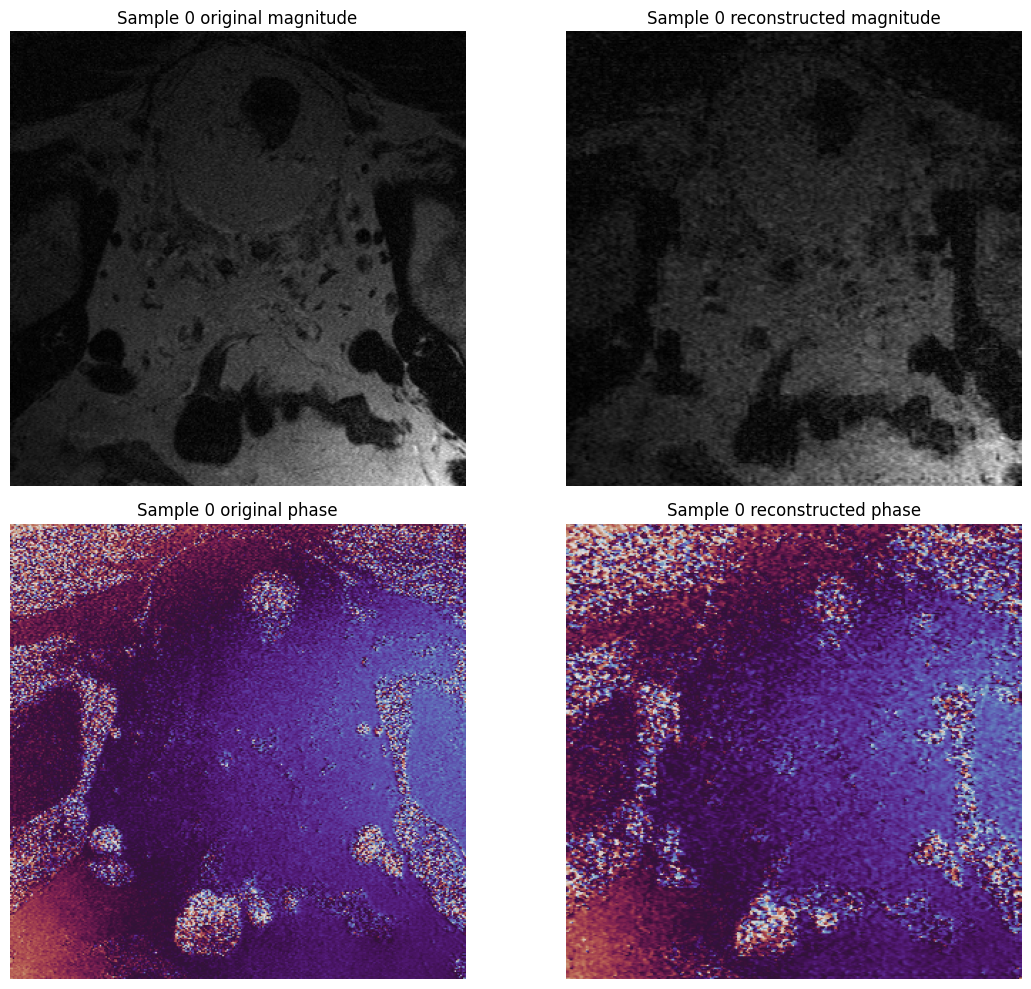

Sample 1: path=/home/mad07/Datasets/Prostate MRI/t2_samples/features/test/t2_pt_id_04_slice_01_coil_02.npy mse=1.248830e-11 nmse=2.930818e-01


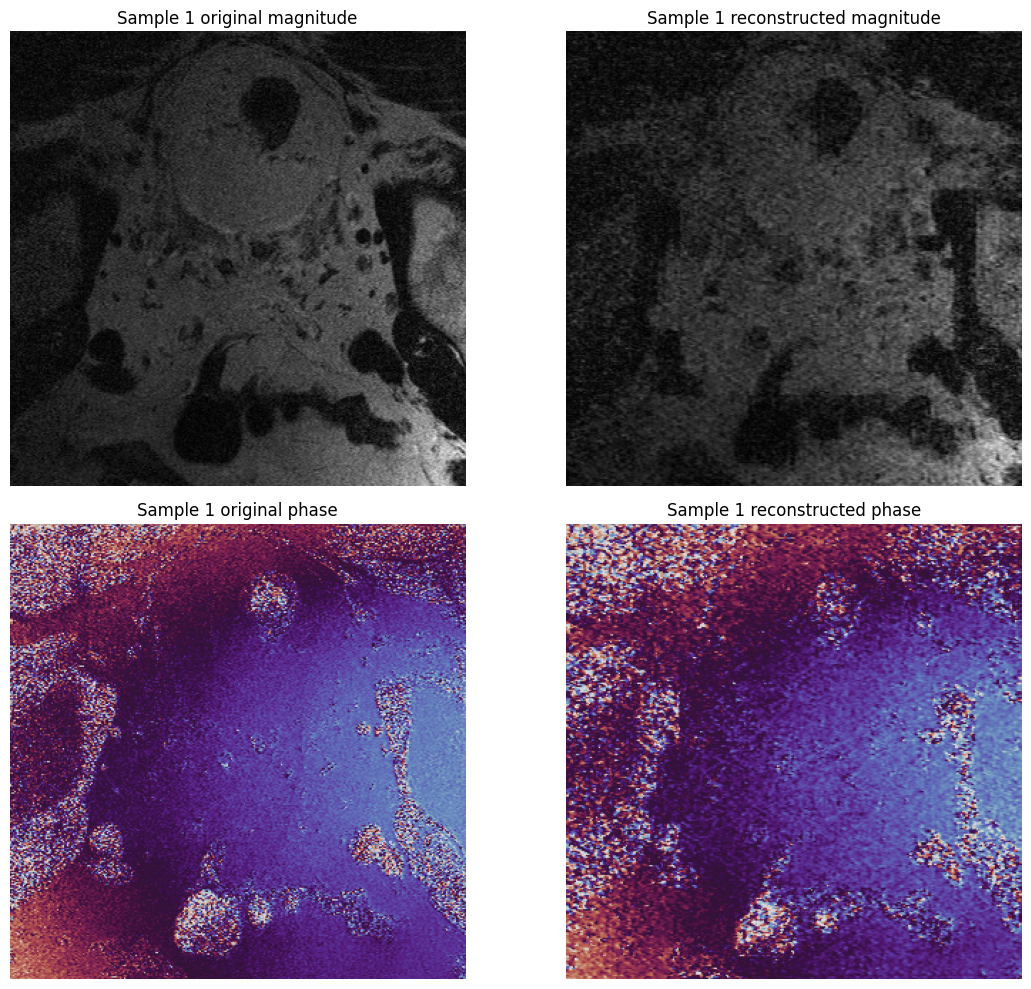

Sample 2: path=/home/mad07/Datasets/Prostate MRI/t2_samples/features/test/t2_pt_id_04_slice_01_coil_03.npy mse=2.580156e-11 nmse=2.363529e-01


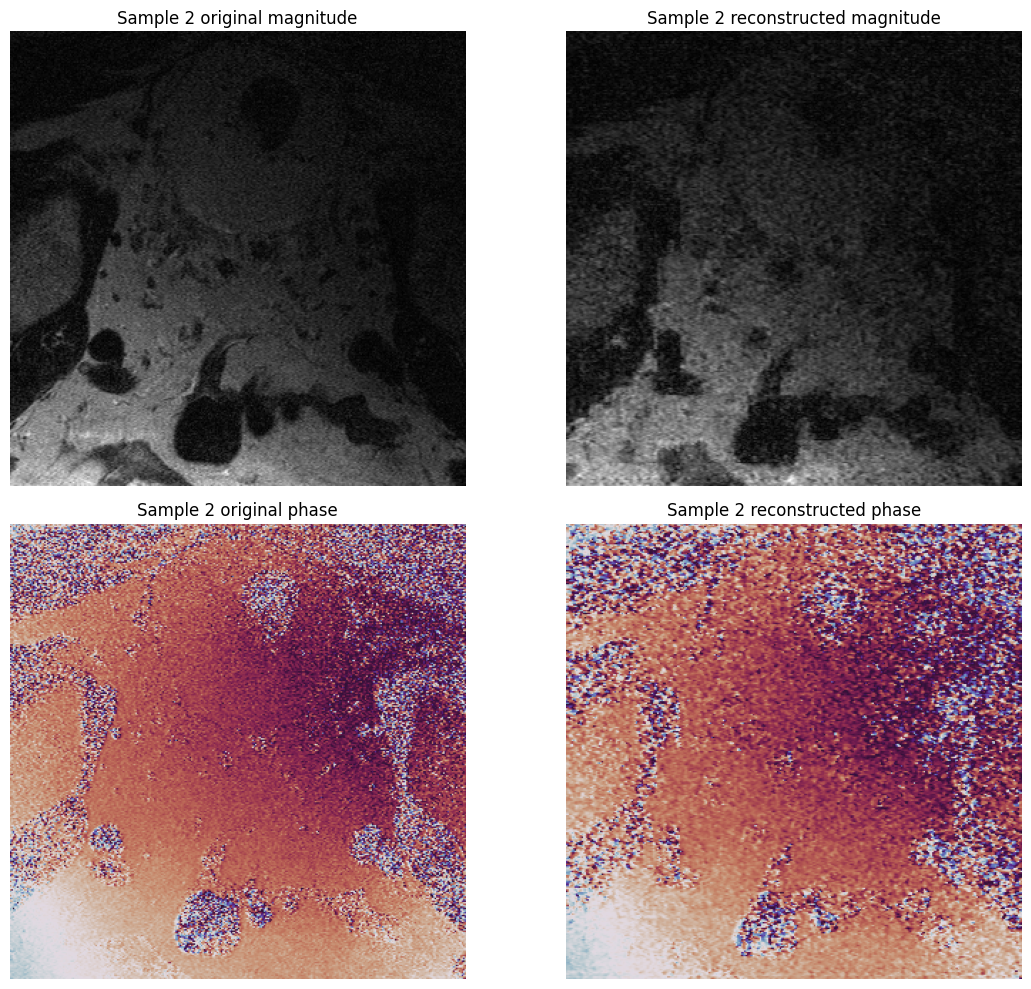

Sample 3: path=/home/mad07/Datasets/Prostate MRI/t2_samples/features/test/t2_pt_id_04_slice_01_coil_04.npy mse=2.619092e-11 nmse=2.195270e-01


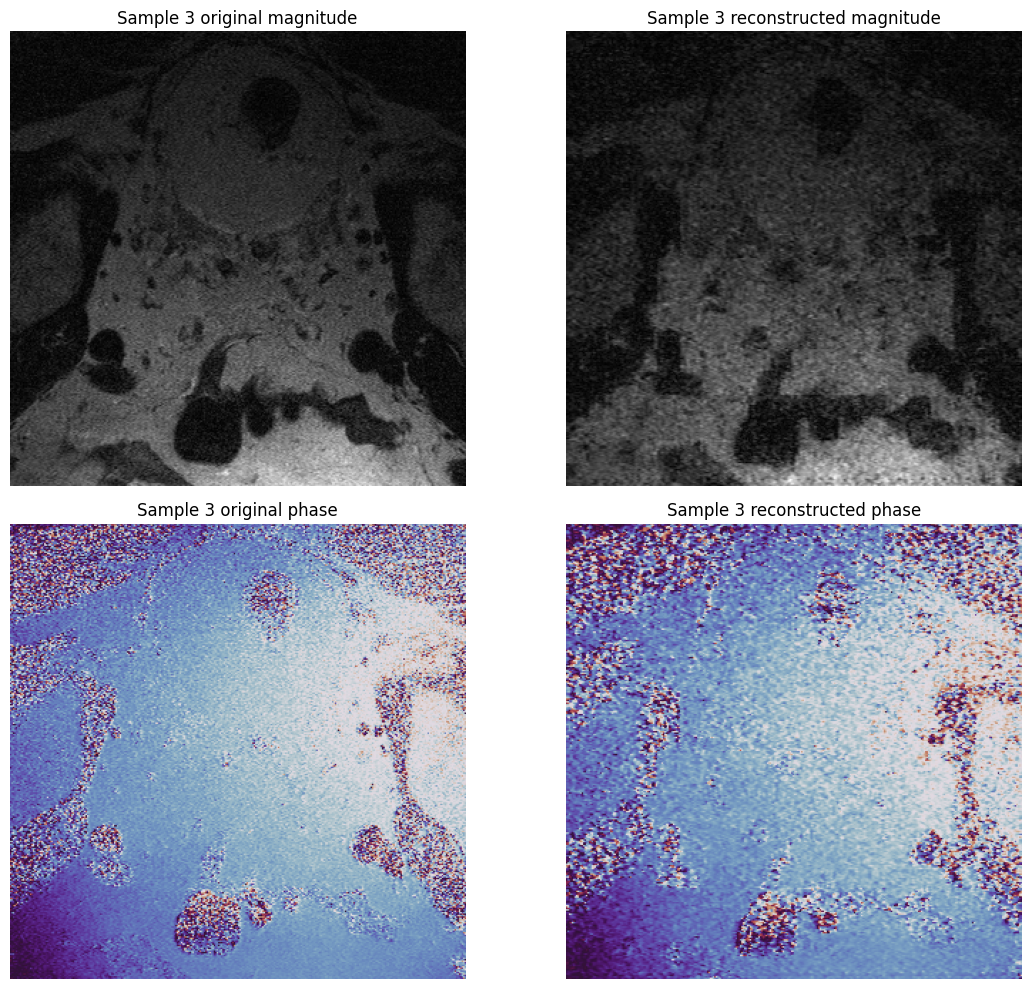

Saved reconstructed sample outputs to: /home/mad07/Datasets/Prostate MRI/complex_t2_autoencoder/reconstructions


In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def reconstruct_sample(sample: dict[str, object]) -> tuple[torch.Tensor, torch.Tensor]:
    image = sample["image"].to(DEVICE)
    scale = sample["scale"]
    with torch.no_grad():
        reconstruction = model(image.unsqueeze(0)).squeeze(0).cpu()
    return image.cpu() * scale, reconstruction * scale

def show_complex_pair(original: torch.Tensor, reconstruction: torch.Tensor, title: str, vmax: float | None = None) -> None:
    original = original.squeeze(0) if original.ndim == 3 else original
    reconstruction = reconstruction.squeeze(0) if reconstruction.ndim == 3 else reconstruction
    original_mag = torch.abs(original).numpy()
    reconstruction_mag = torch.abs(reconstruction).numpy()
    original_phase = torch.angle(original).numpy()
    reconstruction_phase = torch.angle(reconstruction).numpy()

    vmax_value = vmax or max(original_mag.max(), reconstruction_mag.max())
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(original_mag, cmap="gray", norm=Normalize(vmin=0, vmax=vmax_value))
    axes[0, 0].set_title(f"{title} original magnitude")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(reconstruction_mag, cmap="gray", norm=Normalize(vmin=0, vmax=vmax_value))
    axes[0, 1].set_title(f"{title} reconstructed magnitude")
    axes[0, 1].axis("off")
    axes[1, 0].imshow(original_phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[1, 0].set_title(f"{title} original phase")
    axes[1, 0].axis("off")
    axes[1, 1].imshow(reconstruction_phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[1, 1].set_title(f"{title} reconstructed phase")
    axes[1, 1].axis("off")
    plt.tight_layout()
    plt.show()

def save_reconstruction_outputs(index: int, original: torch.Tensor, reconstruction: torch.Tensor, save_dir: Path) -> None:
    save_dir.mkdir(parents=True, exist_ok=True)
    np.save(save_dir / f"original_{index}.npy", original.numpy())
    np.save(save_dir / f"reconstruction_{index}.npy", reconstruction.numpy())
    np.save(save_dir / f"difference_{index}.npy", (original - reconstruction).numpy())

save_dir = output_dir / "reconstructions"
save_dir.mkdir(parents=True, exist_ok=True)

for idx in range(min(4, len(dataset))):
    sample = dataset[idx]
    original, reconstruction = reconstruct_sample(sample)
    mse = float(torch.mean(torch.abs(original - reconstruction) ** 2).item())
    nmse = float(mse / torch.mean(torch.abs(original) ** 2).item())
    print(f"Sample {idx}: path={sample['path']} mse={mse:.6e} nmse={nmse:.6e}")
    show_complex_pair(original, reconstruction, f"Sample {idx}")
    save_reconstruction_outputs(idx, original, reconstruction, save_dir)

print("Saved reconstructed sample outputs to:", save_dir)

## Confusion Matrix for Reconstruction Magnitudes

Compute a confusion matrix between quantized original and reconstructed magnitude bins for the first test sample. This helps visualize whether reconstructions fall into the same intensity ranges as the originals.

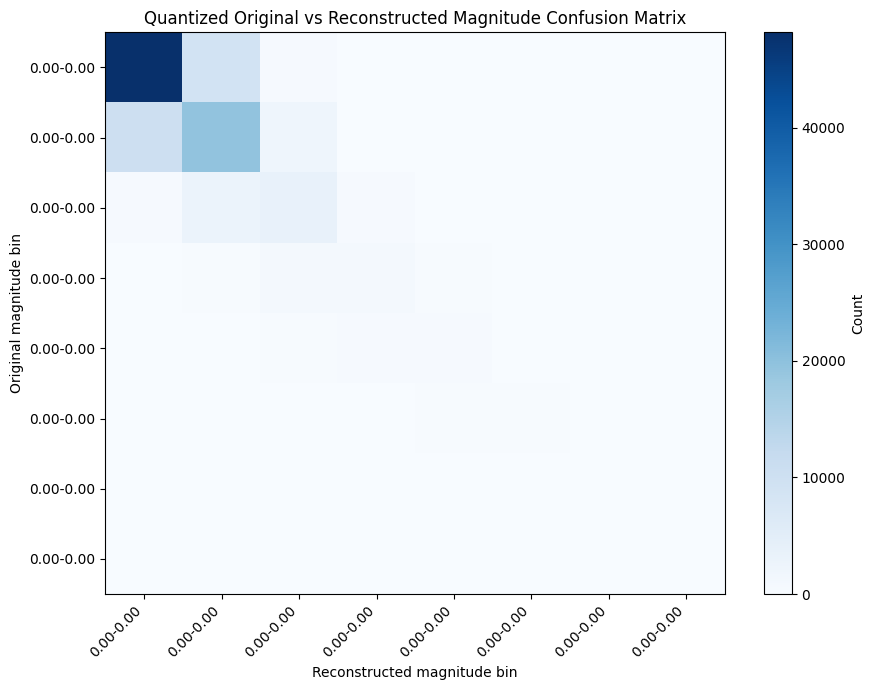

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def quantized_confusion_matrix(original: np.ndarray, reconstruction: np.ndarray, bins: int = 8) -> tuple[np.ndarray, np.ndarray]:
    original = original.squeeze(0) if original.ndim == 3 else original
    reconstruction = reconstruction.squeeze(0) if reconstruction.ndim == 3 else reconstruction
    original = np.abs(original).ravel()
    reconstruction = np.abs(reconstruction).ravel()
    max_val = max(original.max(), reconstruction.max(), 1e-6)
    edges = np.linspace(0.0, max_val, bins + 1)
    original_labels = np.clip(np.digitize(original, edges, right=False) - 1, 0, bins - 1)
    reconstruction_labels = np.clip(np.digitize(reconstruction, edges, right=False) - 1, 0, bins - 1)
    cm = np.zeros((bins, bins), dtype=int)
    for o, r in zip(original_labels, reconstruction_labels):
        cm[o, r] += 1
    return cm, edges

if len(dataset) == 0:
    print("No test samples available to compute a confusion matrix.")
else:
    sample = dataset[0]
    original, reconstruction = reconstruct_sample(sample)
    original = original.numpy() if isinstance(original, np.ndarray) else original.numpy()
    reconstruction = reconstruction.numpy() if isinstance(reconstruction, np.ndarray) else reconstruction.numpy()
    cm, edges = quantized_confusion_matrix(original, reconstruction, bins=8)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_title("Quantized Original vs Reconstructed Magnitude Confusion Matrix")
    ax.set_xlabel("Reconstructed magnitude bin")
    ax.set_ylabel("Original magnitude bin")
    bins_labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(len(edges) - 1)]
    ax.set_xticks(np.arange(len(bins_labels)))
    ax.set_yticks(np.arange(len(bins_labels)))
    ax.set_xticklabels(bins_labels, rotation=45, ha="right")
    ax.set_yticklabels(bins_labels)
    fig.colorbar(im, ax=ax, label="Count")
    plt.tight_layout()
    plt.show()
